In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
import joblib

In [2]:
# --- 1. Funciones de utilidad (Necesarias para la preparación del DF) ---

# Replicamos las funciones esenciales para asegurar la ejecución del pipeline completo.
def agregar_lags(df, columna, lags):
    for lag in lags:
        df[f'lag_{lag}'] = df[columna].shift(lag)
    return df

def agregar_medias_moviles(df, columna, ventanas):
    for ventana in ventanas:
        df[f'media_movil_{ventana}'] = df[columna].shift(1).rolling(window=ventana, min_periods=1).mean()
    return df

def agregar_variables_ciclicas(df, columna_mes, columna_fecha):
    df['mes_sin'] = np.sin(2 * np.pi * df[columna_mes] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df[columna_mes] / 12)
    df['dia_semana_sin'] = np.sin(2 * np.pi * pd.to_datetime(df[columna_fecha]).dt.weekday / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * pd.to_datetime(df[columna_fecha]).dt.weekday / 7)
    return df

def agregar_ewma(df, columna, spans):
    for span in spans:
        df[f'ewma_{span}'] = df[columna].shift(1).ewm(span=span, adjust=False).mean()
    return df

def obtener_semestre(mes):
    if 3 <= mes <= 7:
        return 1
    elif 8 <= mes <= 12:
        return 2
    else:
        return 0

def semana_en_semestre(row):
    if row['Semestre'] == 1:
        inicio = pd.Timestamp(year=row['Año'], month=3, day=1)
    elif row['Semestre'] == 2:
        inicio = pd.Timestamp(year=row['Año'], month=8, day=1)
    else:
        return np.nan
    return ((row['Fecha'] - inicio).days // 7) + 1

In [3]:
# --- 2. Preparación de Datos y Data Augmentation ---

try:
    daily_counts_full = pd.read_csv("Datasets/daily_counts_full.csv")
    print("Dataset cargado desde 'Datasets/daily_counts_full.csv'")
except FileNotFoundError:
    print("ERROR: No se encontró el archivo 'daily_counts_full.csv'.")
    exit(1)

# A. Feature Engineering 
for col in ['Accesos']:
    daily_counts_full[col] = daily_counts_full[col].fillna(0).astype(int)
daily_counts_full['Fecha'] = pd.to_datetime(daily_counts_full['Fecha'])
daily_counts_full = daily_counts_full[
    daily_counts_full['Fecha'].dt.weekday != 6 
].reset_index(drop=True)

daily_counts_full = agregar_medias_moviles(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full = agregar_variables_ciclicas(daily_counts_full, 'Mes', 'Fecha')
daily_counts_full = agregar_ewma(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full['Semestre'] = daily_counts_full['Mes'].apply(obtener_semestre)
daily_counts_full['Semana_Semestre'] = daily_counts_full.apply(semana_en_semestre, axis=1)
daily_counts_full['Semana_Certamen'] = daily_counts_full['Semana_Semestre'].isin([6, 7]).astype(int)
daily_counts_full = agregar_lags(daily_counts_full, 'Accesos', [7, 14, 21])

# B. División de datos
daily_counts_full = daily_counts_full.dropna().reset_index(drop=True)

FEATURES = ['Vacaciones', 'Semana_Certamen', 'media_movil_7', 'media_movil_14', 'media_movil_30',
            'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
            'lag_7', 'lag_14', 'lag_21', 'ewma_7', 'ewma_14', 'ewma_30']
TARGET = 'Accesos'

X = daily_counts_full[FEATURES]
y = daily_counts_full[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# C. Data Augmentation (Idéntico a RF y LightGBM)
X_train_aug = [X_train.copy()]
y_train_aug = [y_train.copy()]
N_AUGMENTATIONS = 4

for i in range(N_AUGMENTATIONS):
    if i % 2 == 0:
        y_new = y_train * np.random.uniform(0.95, 1.05, len(y_train))
    else:
        y_new = y_train + np.random.normal(0, y_train.std() * 0.02, len(y_train))
    
    df_new = X_train.copy()
    df_new['Accesos'] = y_new

    df_new = df_new.drop(columns=[col for col in df_new.columns if 'media_movil' in col or 'ewma' in col or 'lag_' in col], errors='ignore')
    df_new = agregar_medias_moviles(df_new, 'Accesos', [7, 14, 30])
    df_new = agregar_ewma(df_new, 'Accesos', [7, 14, 30])
    df_new = agregar_lags(df_new, 'Accesos', [7, 14, 21])

    df_new = df_new.dropna().reset_index(drop=True)
    
    X_train_aug.append(df_new[FEATURES])
    y_train_aug.append(df_new['Accesos'])

X_train_final = pd.concat(X_train_aug)
y_train_final = pd.concat(y_train_aug)

print(f"\n--- Preparación de Datos Finalizada ---")
print(f"Tamaño final del set de entrenamiento: {len(X_train_final)} muestras.")

Dataset cargado desde 'Datasets/daily_counts_full.csv'

--- Preparación de Datos Finalizada ---
Tamaño final del set de entrenamiento: 1196 muestras.


In [4]:
# --- 3. Ajuste (Tuning) y Entrenamiento del Modelo ---

# Usamos TimeSeriesSplit para la validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Parámetros para Regresión Ridge: El alfa (alpha) es el término de regularización (lambda).
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag'] # Diferentes solucionadores para el algoritmo
}

print("\nIniciando ajuste de hiperparámetros de Regresión Ridge...")

model_filename = 'Archivos Auxiliares/modelo_Ridge.pkl'
os.makedirs(os.path.dirname('Archivos Auxiliares/'), exist_ok=True)


# 1. Búsqueda de Hyperparámetros
grid_search = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_final, y_train_final)

print(f'Mejores parámetros para Regresión Ridge: {grid_search.best_params_}')

# 2. Entrenamiento del modelo final con los mejores parámetros
best_params = grid_search.best_params_
model = Ridge(**best_params, random_state=42)
model.fit(X_train_final, y_train_final)

# Guardar el modelo
joblib.dump(model, model_filename)
print(f"Modelo Ridge Regression guardado como '{model_filename}'")


Iniciando ajuste de hiperparámetros de Regresión Ridge...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros para Regresión Ridge: {'alpha': 10.0, 'solver': 'auto'}
Modelo Ridge Regression guardado como 'Archivos Auxiliares/modelo_Ridge.pkl'



--- Evaluación de rendimiento de Regresión Ridge en el set de prueba ---
R²: 0.71
Error Cuadrático Medio (MSE): 638712.11
Error Cuadrático Medio Raíz (RMSE): 799.19
Error Absoluto Medio (MAE): 619.03


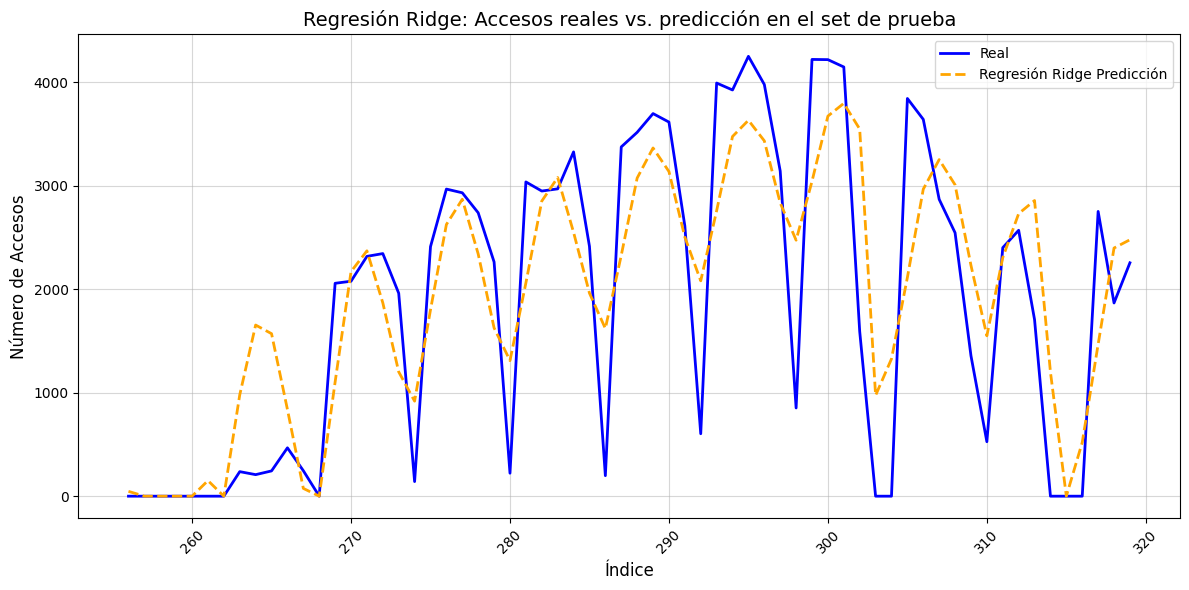

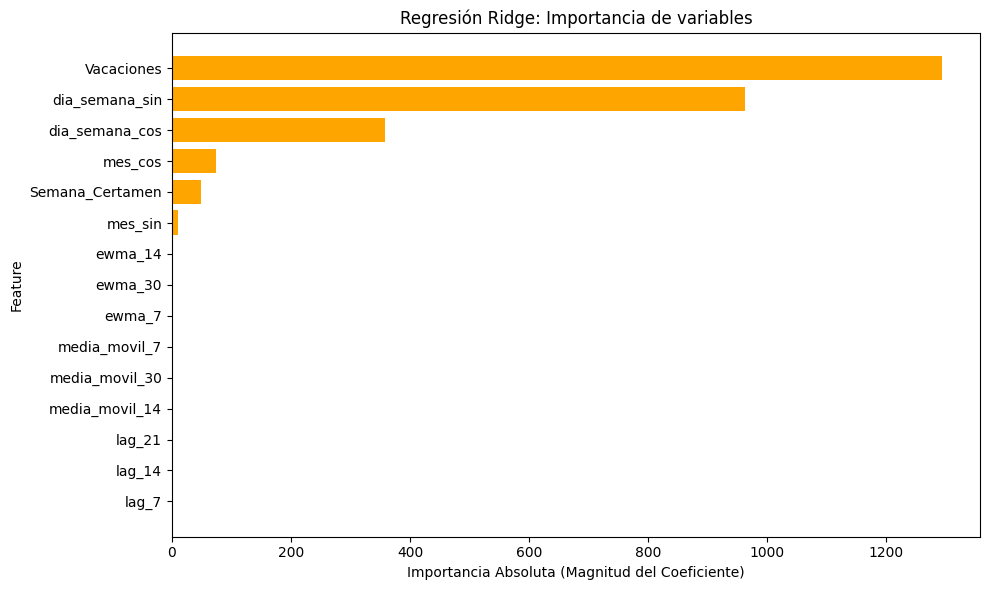

In [5]:
# --- 4. Evaluación de rendimiento ---
predicted = model.predict(X_test)
predicted = np.maximum(predicted, 0)

# Cálculo de métricas
mse = mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)

print("\n--- Evaluación de rendimiento de Regresión Ridge en el set de prueba ---")
print(f"R²: {r2:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Error Cuadrático Medio Raíz (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")


# --- 5. Visualización ---

# Graficar resultados de la predicción
results_df = pd.DataFrame({
    'Índice': X_test.index,
    'Real': y_test,
    'Predicción': predicted
}).sort_values(by='Índice')

plt.figure(figsize=(12, 6))
plt.plot(results_df['Índice'], results_df['Real'], label='Real', color='blue', linewidth=2)
plt.plot(results_df['Índice'], results_df['Predicción'], label='Regresión Ridge Predicción', color='orange', linestyle='--', linewidth=2)
plt.title('Regresión Ridge: Accesos reales vs. predicción en el set de prueba', fontsize=14)
plt.xlabel('Índice', fontsize=12)
plt.ylabel('Número de Accesos', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# Importancia de variables (coeficientes para un modelo lineal)
# Calculamos el valor absoluto de los coeficientes para la importancia
importance_values = np.abs(model.coef_)
importance_df = pd.DataFrame({"Feature": FEATURES, "Importance": importance_values})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='orange')
plt.xlabel("Importancia Absoluta (Magnitud del Coeficiente)")
plt.ylabel("Feature")
plt.title("Regresión Ridge: Importancia de variables")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()